In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("india_2000_2024_daily_weather.csv")
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [3]:
df.columns

Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')

In [4]:
df.groupby("city")["temperature_2m_max"].mean().sort_values(ascending=False)

city
Ahmedabad    33.150142
Chennai      31.896890
Hyderabad    31.230103
Jaipur       31.114893
Lucknow      30.768780
Pune         30.691962
Kolkata      30.684932
Delhi        30.641349
Mumbai       30.513184
Bangalore    28.316798
Name: temperature_2m_max, dtype: float64

In [6]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.3 MB/s  0:00:00m 9.3 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.5 MB/s  0:00:000.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.8 MB/s  0:00:014.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


Matplotlib is building the font cache; this may take a moment.


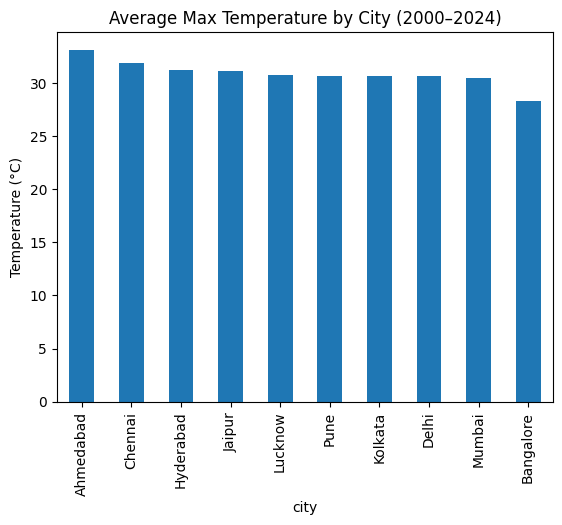

In [7]:
import matplotlib.pyplot as plt

df.groupby("city")["temperature_2m_max"].mean()\
  .sort_values(ascending=False)\
  .plot(kind="bar")

plt.title("Average Max Temperature by City (2000–2024)")
plt.ylabel("Temperature (°C)")
plt.show()

In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df["year"] = df["date"].dt.year

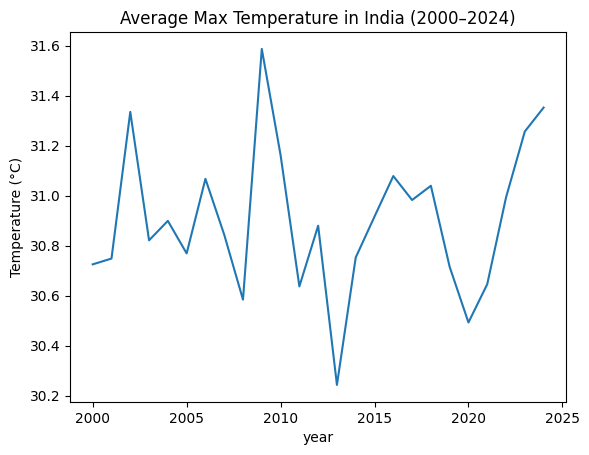

In [10]:
df.groupby("year")["temperature_2m_max"].mean().plot()
plt.title("Average Max Temperature in India (2000–2024)")
plt.ylabel("Temperature (°C)")
plt.show()

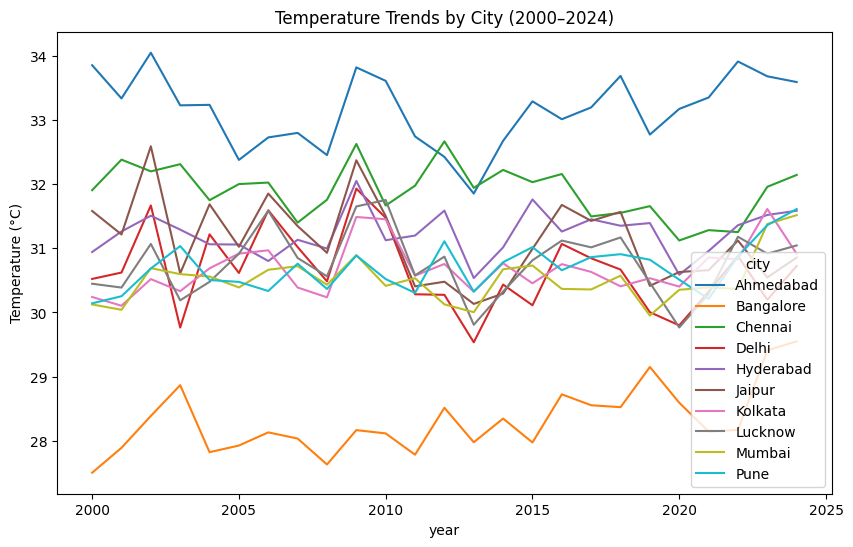

In [11]:
df.groupby(["year", "city"])["temperature_2m_max"].mean().unstack().plot(figsize=(10,6))

plt.title("Temperature Trends by City (2000–2024)")
plt.ylabel("Temperature (°C)")
plt.show()

In [13]:
!pip install seaborn

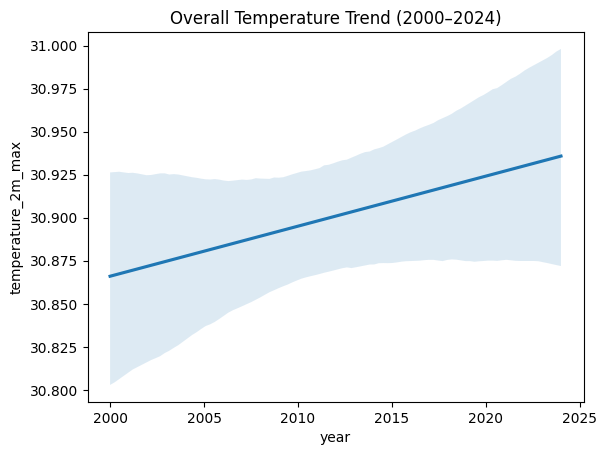

In [14]:
import seaborn as sns

sns.regplot(x="year", y="temperature_2m_max", data=df, scatter=False)

plt.title("Overall Temperature Trend (2000–2024)")
plt.show()

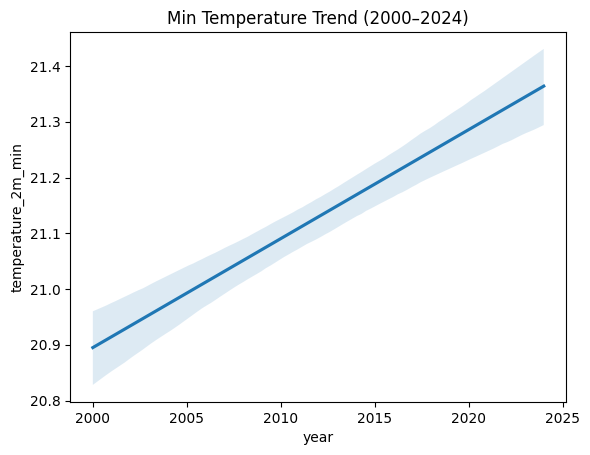

In [15]:
sns.regplot(x="year", y="temperature_2m_min", data=df, scatter=False)

plt.title("Min Temperature Trend (2000–2024)")
plt.show()

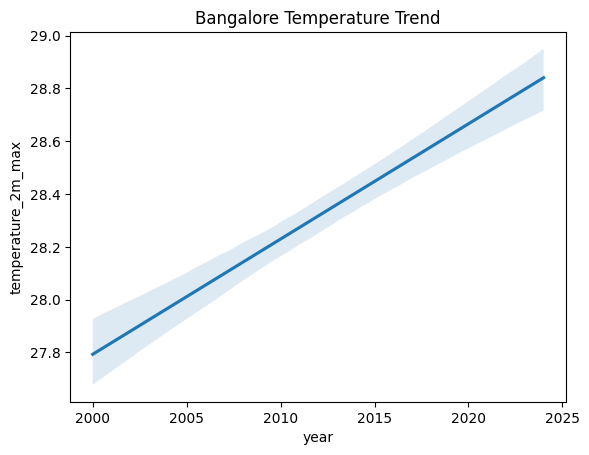

In [16]:
blr = df[df["city"] == "Bangalore"]

sns.regplot(x="year", y="temperature_2m_max", data=blr, scatter=False)
plt.title("Bangalore Temperature Trend")
plt.show()

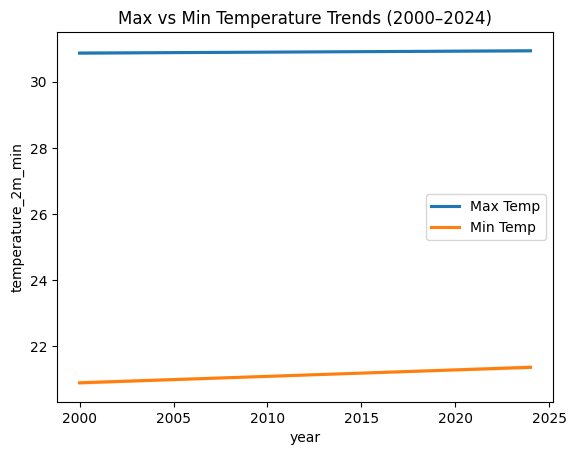

In [17]:
import seaborn as sns

sns.regplot(x="year", y="temperature_2m_max", data=df, scatter=False, label="Max Temp")
sns.regplot(x="year", y="temperature_2m_min", data=df, scatter=False, label="Min Temp")

plt.legend()
plt.title("Max vs Min Temperature Trends (2000–2024)")
plt.show()

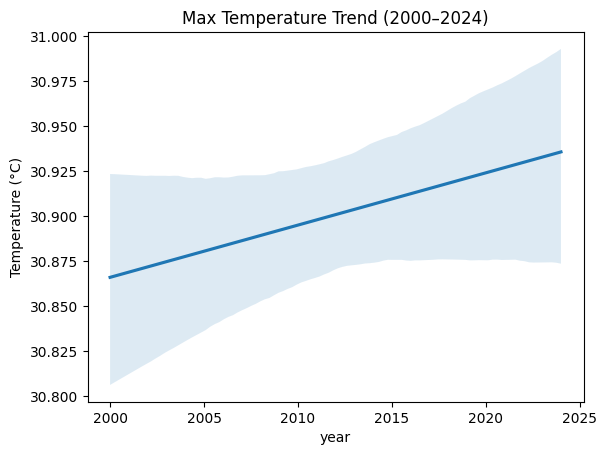

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="year", y="temperature_2m_max", data=df, scatter=False)

plt.title("Max Temperature Trend (2000–2024)")
plt.ylabel("Temperature (°C)")
plt.show()

In [19]:
yearly = df.groupby("year")["temperature_2m_max"].mean().reset_index()

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(yearly["year"], yearly["temperature_2m_max"])

print("Yearly increase in max temperature:", slope)
print("R-squared:", r_value**2)

Yearly increase in max temperature: 0.0028966753614676553
R-squared: 0.00514108044502654


In [21]:
yearly = df.groupby("year")[["temperature_2m_max", "temperature_2m_min"]].mean().reset_index()

In [22]:
from scipy.stats import linregress

slope_min, _, r_min, _, _ = linregress(yearly["year"], yearly["temperature_2m_min"])

print("Min temp slope:", slope_min)
print("R-squared:", r_min**2)

Min temp slope: 0.019523839186489013
R-squared: 0.27377282751540916


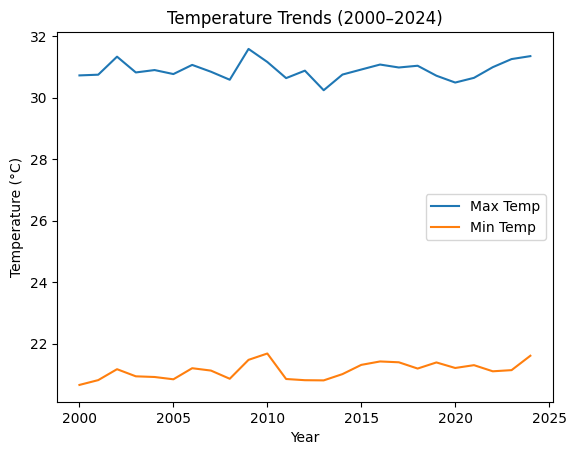

In [23]:
import matplotlib.pyplot as plt

plt.plot(yearly["year"], yearly["temperature_2m_max"], label="Max Temp")
plt.plot(yearly["year"], yearly["temperature_2m_min"], label="Min Temp")

plt.legend()
plt.title("Temperature Trends (2000–2024)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.show()